In [57]:
import jax

jax.config.update("jax_enable_x64", True)

from flax import linen as nn, struct
from flax.training.train_state import TrainState
from jax.flatten_util import ravel_pytree
from optax import softmax_cross_entropy_with_integer_labels as xent
from typing import Literal
import jax
import jax.numpy as jnp
import optax


class MLP(nn.Module):
    hidden_sizes: tuple[int, ...]
    out_features: int

    @nn.compact
    def __call__(self, x):
        for feat in self.hidden_sizes:
            scale = feat**-0.5
            bias_init = nn.initializers.normal(stddev=scale)

            x = nn.Dense(feat, bias_init=bias_init)(x)
            x = nn.gelu(x)

        x = nn.Dense(self.out_features, bias_init=bias_init)(x)
        return x


@struct.dataclass
class TrainConfig:
    batch_size: int = 320
    num_epochs: int = 25

    opt: str = "sgd"


def make_apply_full(model, unraveler):
    """Make an apply function that takes the full parameter vector."""

    def apply_full(raveled, x):
        params = unraveler(raveled)
        return model.apply(params, x)

    return apply_full


def make_apply_subspace(model, unraveler, params0, basis):
    """Make an apply function that takes a small parameter vector."""

    def apply_subspace(small_params, x):
        raveled = params0 + basis.T @ small_params
        return model.apply(unraveler(raveled), x)

    return apply_subspace


# Loss function
def compute_loss(params, apply_fn, weights, X, Y):
    logits = apply_fn(params["p"], X)
    preds = jnp.argmax(logits, axis=-1)

    loss = jnp.sum(weights * xent(logits, Y))
    acc = jnp.mean(preds == Y)
    return loss, acc


# Forward and backward pass
loss_and_grad = jax.value_and_grad(compute_loss, has_aux=True)


import jax
from jax import random, grad, jvp


def hutchinson_hdiag(f, theta, *fargs, n=64, dist="rademacher", has_aux=False):
    """
    Estimate diag(∇²_θ f(θ, *fargs)) via Hutchinson:  E[v ⊙ (H v)].

    Args:
        f: scalar-valued function f(theta, *fargs)
        theta: pytree of parameters (leaves float arrays)
        *fargs: extra args passed to f
        key: PRNGKey
        n: number of probe vectors
        dist: "rademacher" (±1) or "gaussian" (N(0,1))

    Returns:
        pytree with same structure as theta containing the diagonal estimate.
    """
    key = jax.random.key(0)
    theta_flat, unravel = ravel_pytree(theta)

    def f_flat(vec):
        return f(unravel(vec), *fargs)

    g_flat = grad(f_flat, has_aux=has_aux)

    def hvp(v):
        # H v = JVP(∇f, v)
        Hv = jvp(g_flat, (theta_flat,), (v,), has_aux=has_aux)[1]
        return Hv

    D = theta_flat.shape[0]
    k1, key = random.split(key)
    if dist == "rademacher":
        v = random.rademacher(k1, (n, D), dtype=theta_flat.dtype)
    elif dist == "gaussian":
        v = random.normal(k1, (n, D), dtype=theta_flat.dtype)
    else:
        raise ValueError("dist must be 'rademacher' or 'gaussian'")

    Hv = jax.vmap(hvp)(v)  # (n, D)
    diag_est_flat = jnp.mean(v * Hv, axis=0)  # (D,)
    return unravel(diag_est_flat)


def train(
    params,
    weights,
    x_train,
    y_train,
    x_test,
    y_test,
    apply_fn,
    cfg: TrainConfig,
    mode: Literal["hessian", "hutch", "grads", "vanilla"] = "vanilla",
):
    x_train, y_train = jnp.array(x_train), jnp.array(y_train)
    weights = jax.nn.softmax(weights)

    # Create a key for each epoch
    master = jax.random.key(0)
    keys = jax.random.split(master, cfg.num_epochs)

    # LR schedule
    num_steps = cfg.num_epochs * len(x_train) // cfg.batch_size

    # Define the optimizer and training state
    if cfg.opt == "adam":
        sched = optax.cosine_decay_schedule(3e-3, num_steps)
        tx = optax.adam(learning_rate=sched, b2=0.95, eps_root=1e-8)
    else:
        # sched = optax.cosine_decay_schedule(1.0, num_steps)
        tx = optax.chain(optax.sgd(learning_rate=1.0, momentum=0.0))

    state = TrainState.create(apply_fn=apply_fn, params=dict(p=params), tx=tx)

    def train_step(state: TrainState, batch):
        (loss, acc), grad = loss_and_grad(state.params, state.apply_fn, *batch)
        if mode == "hessian":
            aux, _ = jax.hessian(compute_loss, has_aux=True)(
                state.params, state.apply_fn, *batch
            )
            aux = aux["p"]["p"]
        elif mode == "hutch":
            aux = hutchinson_hdiag(
                compute_loss, state.params, state.apply_fn, *batch, has_aux=True, n=1024
            )
            aux = aux["p"]
        elif mode == "grads":
            _, aux = jax.vmap(loss_and_grad, in_axes=(None, None, 0, 0, 0))(
                state.params, state.apply_fn, *batch
            )
        else:
            aux = None

        return state.apply_gradients(grads=grad), (loss, acc, aux)

    def epoch_step(state: TrainState, key):
        # Re-shuffle the data
        perm = jax.random.permutation(key, len(x_train))
        x_train_perm = x_train[perm]
        y_train_perm = y_train[perm]
        weights_perm = weights[perm]

        weights_batched = jnp.reshape(weights_perm, (-1, cfg.batch_size))
        X_batched = jnp.reshape(x_train_perm, (-1, cfg.batch_size, 64))
        Y_batched = jnp.reshape(y_train_perm, (-1, cfg.batch_size))

        state, (losses, accs, aux) = jax.lax.scan(
            train_step, state, (weights_batched, X_batched, Y_batched)
        )
        return state, (losses.mean(), accs.mean(), aux)

    state, (train_loss, _, aux) = jax.lax.scan(epoch_step, state, keys)
    raveled, _ = ravel_pytree(state.params)

    if mode in ("hessian", "hutch", "grads"):
        return raveled, aux
    elif mode == "vanilla":
        # logits = state.apply_fn(state.params['p'], x_test)
        # test_loss = xent(logits, y_test).mean()
        return raveled
    else:
        raise ValueError(f"Unknown mode {mode}")


In [58]:
def pearson_corr(x: jnp.ndarray, y: jnp.ndarray, axis=-1):
    """
    Compute the Pearson correlation coefficient of x and y along the given axis.

    Args:
        x, y: jnp.ndarray of the same shape.
        axis: int, the axis along which to compute correlation.

    Returns:
        jnp.ndarray: correlation coefficients with the given axis removed.
    """
    x_mean = jnp.mean(x, axis=axis, keepdims=True)
    y_mean = jnp.mean(y, axis=axis, keepdims=True)
    xm = x - x_mean
    ym = y - y_mean

    cov = jnp.sum(xm * ym, axis=axis)
    x_std = jnp.sqrt(jnp.sum(xm**2, axis=axis))
    y_std = jnp.sqrt(jnp.sum(ym**2, axis=axis))

    eps = jnp.finfo(x.dtype).tiny
    return cov / (x_std * y_std + eps)


pearson_corr(
    jnp.var(grads["p"], axis=-2),
    jnp.linalg.diagonal(hesses),
).mean()

Array(0.92018634, dtype=float32)

In [59]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


# Load data
X, Y = load_digits(return_X_y=True)
X = X / 16.0  # Normalize

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=197, random_state=0)
spectra = []

loo_weights = jnp.diag(jnp.full(len(X_train), -jnp.inf))
uniform = jnp.ones(len(X_train)) / len(X_train)
d_inner = X.shape[1] // 2

model = MLP(hidden_sizes=(d_inner,), out_features=10)

# Do a single run with seed 0 to get the Jac
key = jax.random.key(0)

params_0 = model.init(key, X_train)
raveled_0, unraveler = ravel_pytree(params_0)
apply_fn = make_apply_full(model, unraveler)

# loo_losses = loo_train(raveled_0, loo_weights, X_train, Y_train, X_test, Y_test, apply_fn, TrainConfig(opt="adam"))

In [60]:
warmup_f = train(
    raveled_0,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd", num_epochs=2),
    mode="vanilla",
)
final, hesses = train(
    warmup_f,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd"),
    mode="hessian",
)

In [61]:
_, hutches = train(
    warmup_f,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd"),
    mode="hutch",
)

In [62]:
exact = jax.jacobian(train)(
    warmup_f,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd"),
)

In [63]:
_, grads = train(
    warmup_f,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd"),
    mode="grads",
)

In [64]:
import jax.numpy as jnp
from jax import lax


def ema_associative(x, alpha=0.9, axis=0, init=None, bias_correction=False, eps=1e-12):
    """
    Exponential moving average along `axis` via associative scan.

    Args:
        x: array
        alpha: smoothing factor (0 < alpha <= 1)
        axis: axis over which to compute the EMA
        init: optional initial value y_{-1}; if None, taken as 0
        bias_correction: if True, divide by (1 - (1-alpha)^{t+1}) like Adam
        eps: small constant to avoid divide-by-zero in bias correction

    Returns:
        Array of same shape as x with EMA along `axis`.
    """
    x = jnp.moveaxis(x, axis, 0)  # (T, *rest)
    T = x.shape[0]
    a = 1.0 - alpha
    b = alpha * x  # b_t

    # Scalars per step
    A = jnp.full((T,), a, dtype=x.dtype)  # a_t (constant here)

    def combine(u, v):
        Au, Bu = u  # Au: (...), Bu: (*rest)
        Av, Bv = v
        # Ensure Av broadcasts over Bu/Bv trailing dims
        while Av.ndim < Bu.ndim:
            Av = Av[..., None]
        return (Au * Av.squeeze(), Bu * Av + Bv)

    # Prefix associative scan over time
    A_pref, B_pref = lax.associative_scan(
        combine, (A, b)
    )  # A_pref[t]=a^{t+1}, B_pref[t]=sum_{k<=t} b_k a^{t-k}

    # Build EMA
    if init is None:
        y = B_pref
    else:
        init = jnp.asarray(init, dtype=x.dtype)
        # Broadcast init over trailing dims
        while init.ndim < x.ndim - 1:
            init = init[None, ...]
        # A_pref currently has shape (T,), lift to match y
        A_bc = A_pref
        while A_bc.ndim < B_pref.ndim:
            A_bc = A_bc[..., None]
        y = A_bc * init + B_pref

    if bias_correction:
        denom = 1.0 - A_pref
        # Broadcast denom
        denom_bc = denom
        while denom_bc.ndim < y.ndim:
            denom_bc = denom_bc[..., None]
        y = y / (denom_bc + eps)

    return jnp.moveaxis(y, 0, axis)


In [65]:
hutches

Array([[[ 2.31613498e-03,  2.84401281e-03,  5.36601106e-03, ...,
          3.32920608e-04,  2.61082372e-04,  9.94950096e-05],
        [ 3.29989428e-03,  2.78053852e-03,  5.60929393e-03, ...,
          3.54421616e-04,  3.05734866e-04,  1.60113501e-04],
        [ 2.59229168e-03,  1.69990631e-03,  6.69537950e-03, ...,
          4.19300457e-04,  2.39420886e-04,  2.47055315e-04],
        [ 3.67135089e-03,  1.94935501e-03,  6.44612592e-03, ...,
          3.96639807e-04,  2.75385042e-04,  1.89522427e-04],
        [ 4.44449950e-03,  2.52805580e-03,  7.35460129e-03, ...,
          4.26731829e-04,  3.05515568e-04,  2.07451230e-04]],

       [[ 4.47763689e-03,  2.83555174e-03,  9.29347426e-03, ...,
          4.34644026e-04,  2.52923230e-04,  3.06845468e-04],
        [ 4.17123828e-03,  2.23241327e-03,  6.10984443e-03, ...,
          4.03190759e-04,  2.22118601e-04,  2.37611574e-04],
        [ 4.55723563e-03,  2.65858695e-03,  6.98419940e-03, ...,
          4.03023354e-04,  2.74287566e-04,  1.22389

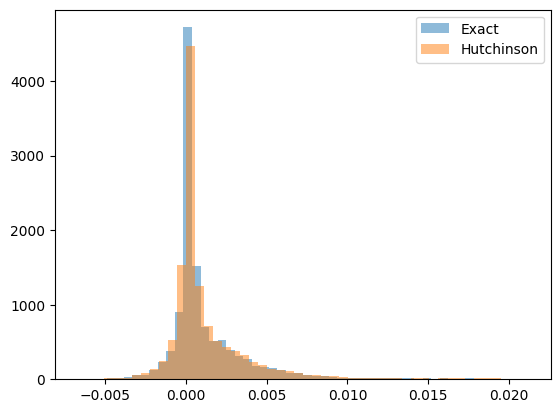

In [66]:
import matplotlib.pyplot as plt

plt.hist(jnp.linalg.diagonal(hesses)[1].flatten(), bins=50, label="Exact", alpha=0.5)
plt.hist(hutches[1].flatten(), bins=50, label="Hutchinson", alpha=0.5)
plt.legend()

In [67]:
pearson_corr(hutches, jnp.linalg.diagonal(hesses))

Array([[0.9791047 , 0.9786288 , 0.97897714, 0.9788655 , 0.9777807 ],
       [0.97862244, 0.9794371 , 0.978657  , 0.97883564, 0.9794666 ],
       [0.9792597 , 0.97866905, 0.97865486, 0.97970253, 0.9800341 ],
       [0.98049176, 0.98005366, 0.97918093, 0.9791451 , 0.98001933],
       [0.9800121 , 0.97897774, 0.9805923 , 0.98019993, 0.9804318 ],
       [0.9805787 , 0.98066944, 0.9800404 , 0.98054576, 0.98060185],
       [0.98138565, 0.98139465, 0.9808065 , 0.9804183 , 0.9814808 ],
       [0.98044044, 0.9813137 , 0.9811729 , 0.9816925 , 0.9808763 ],
       [0.98131496, 0.98194474, 0.98276764, 0.9816925 , 0.9805349 ],
       [0.9812547 , 0.9819999 , 0.98110145, 0.9818201 , 0.9826472 ],
       [0.9815544 , 0.9829812 , 0.9811872 , 0.98095095, 0.9828287 ],
       [0.9826998 , 0.9833608 , 0.9815245 , 0.98243994, 0.9816255 ],
       [0.9816908 , 0.98361933, 0.98161167, 0.98144156, 0.9821223 ],
       [0.98329884, 0.98113096, 0.9826828 , 0.98290646, 0.9819521 ],
       [0.9824692 , 0.98211205, 0.

In [74]:
# compute training jacobian
hutch_jac = jnp.ones(len(raveled_0))

for epoch_hess in hesses:
    for batch_hess in epoch_hess:
        step_jac = 1.0 - jnp.linalg.diagonal(batch_hess)
        hutch_jac = step_jac * hutch_jac

pearson_corr(
    jnp.diag(exact),
    hutch_jac,
)

Array(-0.38482893, dtype=float64)

In [70]:
hutch_jac

Array([0.26544792, 0.46381793, 0.19716104, ..., 0.96652771, 0.98845644,
       0.99076508], dtype=float64)

In [71]:
jnp.diag(exact)

Array([0.93165386, 0.9722557 , 0.91980606, ..., 1.1147733 , 1.0510715 ,
       1.2163078 ], dtype=float32)

In [69]:
fake_hesses = jnp.var(grads["p"] * TrainConfig().batch_size, axis=-2)

# compute training jacobian
fake_jac = jnp.ones(len(raveled_0))

for epoch_hess in fake_hesses:
    for batch_hess in epoch_hess:
        step_jac = 1.0 - batch_hess
        fake_jac = step_jac * fake_jac

pearson_corr(
    jnp.diag(exact),
    fake_jac,
)

Array(-0.40398033, dtype=float64)

In [35]:
pearson_corr(jnp.diag(exact).flatten(), fake_jac.flatten())

Array(-0.36548799, dtype=float64)

(array([1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 8.000e+00,
        8.000e+00, 1.600e+01, 7.100e+01, 2.302e+03]),
 array([0.99878248, 0.99890423, 0.99902598, 0.99914773, 0.99926949,
        0.99939124, 0.99951299, 0.99963474, 0.9997565 , 0.99987825,
        1.        ]),
 <BarContainer object of 10 artists>)

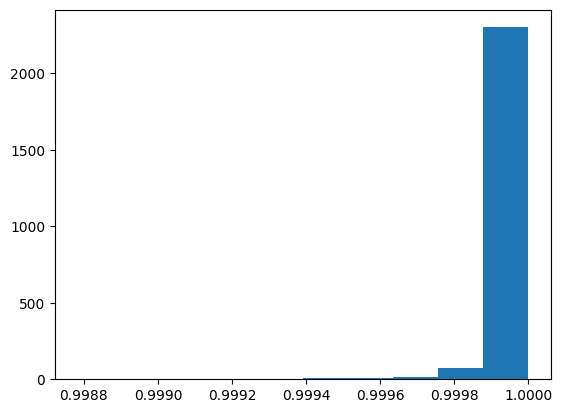

In [40]:
import matplotlib.pyplot as plt

plt.hist(fake_jac)

In [83]:
# compute training jacobian
jac = jnp.eye(len(raveled_0))

for epoch_hess in hesses:
    for batch_hess in epoch_hess:
        step_jac = jnp.eye(len(raveled_0)) - 1.0 * batch_hess
        jac = step_jac @ jac

pearson_corr(jnp.diag(exact), jac.diagonal())

Array(1.00000003, dtype=float64)

In [97]:
# compute training jacobian
const_jac = jnp.eye(len(raveled_0))

for epoch_hess in hesses:
    for batch_hess in epoch_hess:
        step_jac = jnp.eye(len(raveled_0)) - 1.0 * epoch_hess[0]
        const_jac = step_jac @ const_jac

pearson_corr(jnp.diag(const_jac), jnp.diag(exact))

Array(0.97039274, dtype=float64)

In [95]:
# compute training jacobian
diag_jac = jnp.ones(len(raveled_0))

for epoch_hess in hesses:
    for batch_hess in epoch_hess:
        step_jac = 1.0 - jnp.diag(batch_hess)
        diag_jac = step_jac * diag_jac

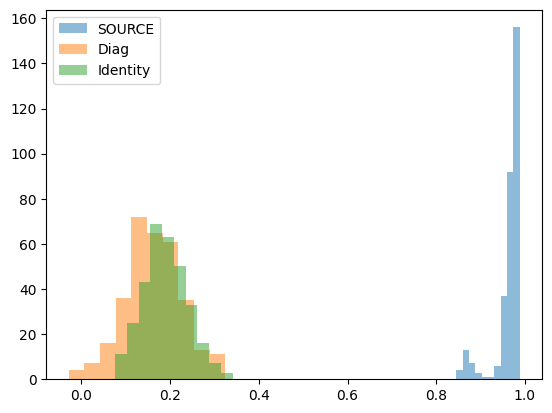

In [104]:
y = grads["p"][0, 0] @ const_jac
x = grads["p"][0, 0] @ exact
sims = optax.losses.cosine_similarity(x, y)

y = grads["p"][0, 0] * diag_jac
sims_diag = optax.losses.cosine_similarity(x, y)
sims_id = optax.losses.cosine_similarity(x, grads["p"][0, 0])

plt.hist(sims, alpha=0.5, label="SOURCE")
plt.hist(sims_diag, alpha=0.5, label="Diag")
plt.hist(sims_id, alpha=0.5, label="Identity")
plt.legend()

In [10]:
tops = jnp.linalg.eigvalsh(hesses)[..., -1]
tops

Array([[0.22411558, 0.21080627, 0.2048659 , 0.20716919, 0.1997651 ,
        0.20100786, 0.19878435, 0.19049412, 0.19304337, 0.19760194],
       [0.19069122, 0.19847898, 0.19683848, 0.18751885, 0.19449872,
        0.1934067 , 0.20689467, 0.20769455, 0.21495903, 0.21143016],
       [0.21643847, 0.21301158, 0.23016998, 0.22236687, 0.23170897,
        0.23822013, 0.23954386, 0.23883344, 0.23912725, 0.24460216],
       [0.24210857, 0.25036582, 0.2624807 , 0.2706149 , 0.26968232,
        0.27510577, 0.28780136, 0.29589084, 0.27667883, 0.27840084],
       [0.3059843 , 0.2947553 , 0.3051343 , 0.3105696 , 0.3130944 ,
        0.3186218 , 0.31034362, 0.3163734 , 0.33496234, 0.32401183],
       [0.33916274, 0.32640874, 0.34920678, 0.36007404, 0.3555973 ,
        0.3600295 , 0.36622578, 0.3833633 , 0.35294905, 0.35667   ],
       [0.3842353 , 0.38137004, 0.3708584 , 0.38596454, 0.38272828,
        0.3821734 , 0.41276625, 0.38547865, 0.4039118 , 0.39608717],
       [0.4136735 , 0.41211623, 0.4371819

In [13]:
tops.flatten()

Array([0.22411558, 0.21080627, 0.2048659 , 0.20716919, 0.1997651 ,
       0.20100786, 0.19878435, 0.19049412, 0.19304337, 0.19760194,
       0.19069122, 0.19847898, 0.19683848, 0.18751885, 0.19449872,
       0.1934067 , 0.20689467, 0.20769455, 0.21495903, 0.21143016,
       0.21643847, 0.21301158, 0.23016998, 0.22236687, 0.23170897,
       0.23822013, 0.23954386, 0.23883344, 0.23912725, 0.24460216,
       0.24210857, 0.25036582, 0.2624807 , 0.2706149 , 0.26968232,
       0.27510577, 0.28780136, 0.29589084, 0.27667883, 0.27840084,
       0.3059843 , 0.2947553 , 0.3051343 , 0.3105696 , 0.3130944 ,
       0.3186218 , 0.31034362, 0.3163734 , 0.33496234, 0.32401183,
       0.33916274, 0.32640874, 0.34920678, 0.36007404, 0.3555973 ,
       0.3600295 , 0.36622578, 0.3833633 , 0.35294905, 0.35667   ,
       0.3842353 , 0.38137004, 0.3708584 , 0.38596454, 0.38272828,
       0.3821734 , 0.41276625, 0.38547865, 0.4039118 , 0.39608717,
       0.4136735 , 0.41211623, 0.43718198, 0.41423133, 0.40567

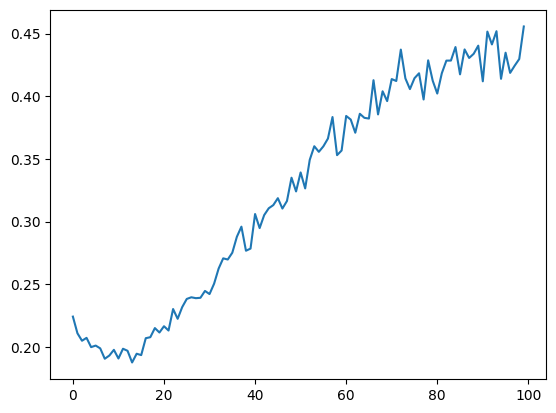

In [17]:
import matplotlib.pyplot as plt

plt.plot(tops.flatten())

In [23]:
optax.losses.cosine_similarity(diag_jac.flatten(), exact.flatten())

Array(0.90293698, dtype=float64)

In [21]:
jnp.mean(jnp.abs(exact - jac))

Array(2.00910447e-10, dtype=float64)

In [2]:
embed_fn = jax.jacfwd(train, argnums=1, has_aux=False)
loo_train = jax.vmap(train, in_axes=(None, 0, None, None, None, None, None, None))

In [4]:
import numpy as np

perm = np.random.permutation(len(X_train))
X2_train = X_train[perm]
Y2_train = Y_train[perm]

influences = embed_fn(
    raveled_0,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="adam"),
)
influences = influences[perm]

influences2 = embed_fn(
    raveled_0,
    uniform,
    X2_train,
    Y2_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="adam"),
)

In [5]:
jnp.corrcoef(influences, influences2)

Array([[0.99999994, 0.93535095],
       [0.93535095, 1.        ]], dtype=float32)

In [6]:
jnp.corrcoef(-influences, loo_losses[perm] - loo_losses.mean())

Array([[0.99999994, 0.9775275 ],
       [0.9775275 , 1.        ]], dtype=float32)

In [148]:
loo_scores = loo_losses - loo_losses.mean()

In [84]:
cold_jac, cold_loss = jac_fn(
    raveled_0,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd"),
)
warm_jac, warm_loss = jac_fn(
    warmup_f,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd"),
)
cold_loss, warm_loss

(Array(0.2500256, dtype=float32), Array(0.2229319, dtype=float32))

In [102]:
warm_embeds, _ = embed_fn(
    warmup_f,
    uniform,
    X_train,
    Y_train,
    X_test,
    Y_test,
    apply_fn,
    TrainConfig(opt="sgd"),
)

In [91]:
uniform_test = jnp.ones(len(X_test))
_, warmup_grads = jax.vmap(loss_and_grad, in_axes=(None, None, 0, 0, 0))(
    dict(p=warmup_f),
    apply_fn,
    uniform_test,
    X_test,
    Y_test,
)
_, final_grads = jax.vmap(loss_and_grad, in_axes=(None, None, 0, 0, 0))(
    dict(p=final),
    apply_fn,
    uniform_test,
    X_test,
    Y_test,
)
warmup_grads["p"].shape

(197, 4810)

In [103]:
warmup_grads["p"] @ warm_embeds

Array([[-6.95167400e-05, -1.53544417e-04, -2.87226867e-05, ...,
         1.20269746e-04, -3.19268147e-05, -2.93251738e-04],
       [ 6.72553142e-04,  4.24046681e-04, -8.44452643e-06, ...,
         2.97232240e-04, -6.37633366e-06,  2.16560424e-04],
       [-4.20233264e-05, -1.53415516e-04, -1.15295998e-05, ...,
         2.75282946e-06, -2.90040152e-05, -3.20005929e-04],
       ...,
       [-5.42993075e-06, -9.35603603e-05, -1.02344720e-05, ...,
        -1.37815325e-04, -1.86572815e-05, -7.87930112e-05],
       [-1.83689524e-04, -8.21339781e-05, -3.37936872e-05, ...,
         3.84622166e-04, -3.04230998e-05, -1.22095502e-04],
       [ 8.25939293e-04,  2.74601742e-04,  2.05644756e-05, ...,
         3.76843440e-04, -1.13116621e-05,  3.52257193e-05]],      dtype=float32)

In [33]:
optax.losses.cosine_similarity(warm_jac.ravel(), jnp.eye(cold_jac.shape[0]).ravel())

Array(0.9462815, dtype=float32)

## Plotting the spectrum

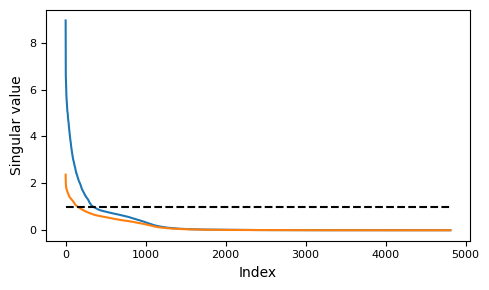

In [34]:
import matplotlib.pyplot as plt

# Define general parameters for plot suitable for LaTeX paper
plt.figure(figsize=(5, 3))  # Adjust figure size to be more paper-friendly
plt.rc("font", size=10)  # Default text size
plt.rc("axes", titlesize=12)  # Title font size
plt.rc("axes", labelsize=10)  # X and Y label size
plt.rc("xtick", labelsize=8)  # X tick label size
plt.rc("ytick", labelsize=8)  # Y tick label size
plt.rc("legend", fontsize=10)  # Legend font size
plt.rc("lines", linewidth=1.5)  # Line width for better visibility in print

# Your plot code
I = jnp.eye(cold_jac.shape[0])
cold_s = jnp.linalg.svdvals(cold_jac - I)
warm_s = jnp.linalg.svdvals(warm_jac - I)
plt.plot(cold_s, label="Cold Jacobian")
plt.plot(warm_s, label="Warm Jacobian")
plt.hlines(1.0, 0, len(cold_s), linestyles="--", colors="black")

# Set axis labels with appropriate sizes
plt.xlabel("Index")
plt.ylabel("Singular value")

# Tight layout to ensure no clipping
plt.tight_layout()

# Show or save the plot
plt.savefig("jac spec.pdf", format="pdf")
plt.show()


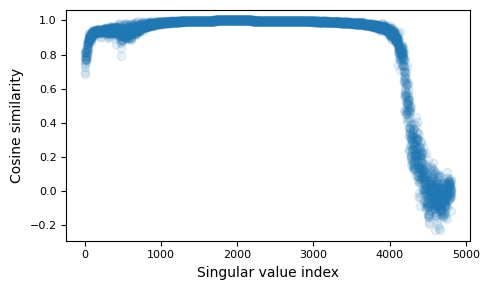

In [28]:
# alignment between left and right singular vectors
sims = jnp.einsum("ij,ji->j", jac_u, jac_vh)

plt.figure(figsize=(5, 3))  # Adjust figure size to be more paper-friendly
plt.scatter(jnp.arange(len(sims)), sims, alpha=0.1)

plt.xlabel("Singular value index")
plt.ylabel("Cosine similarity")

# Tight layout to ensure no clipping
plt.tight_layout()

# Show or save the plot
plt.savefig("cos sims.pdf", format="pdf")
plt.show()

## Finite differences

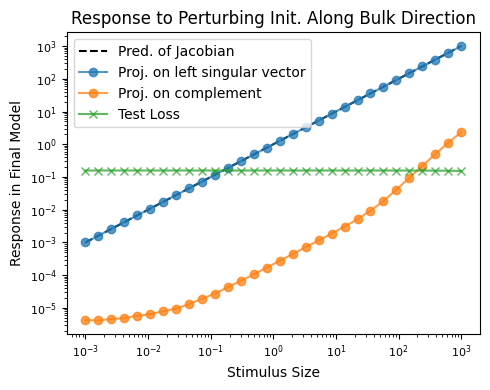

In [36]:
import matplotlib.pyplot as plt

complements = []
bulk_y = []
responses = []

params_f, loss = train(
    params_0, X_train, Y_train, X_test, Y_test, apply_fn, TrainConfig(opt="sgd")
)

num = 2000
grid = jnp.logspace(-3, 3, 30)
for stim in grid:
    perturbed_params, loss = train(
        params_0 + stim * jac_vh[num],
        X_train,
        Y_train,
        X_test,
        Y_test,
        apply_fn,
        TrainConfig(opt="sgd"),
    )
    delta = perturbed_params - params_f
    res = delta @ jac_u[:, num]
    complement = jnp.linalg.norm(delta - res * jac_u[:, num])

    complements.append(complement)
    bulk_y.append(loss)
    responses.append(res)


plt.figure(figsize=(5, 4))  # Adjust figure size to be more paper-friendly
plt.plot(grid, grid * jac_s[num], label="Pred. of Jacobian", c="black", linestyle="--")
plt.plot(
    grid,
    jnp.abs(jnp.array(responses)),
    marker="o",
    label="Proj. on left singular vector",
    alpha=0.75,
)
plt.plot(grid, complements, marker="o", label="Proj. on complement", alpha=0.75)
plt.plot(grid, bulk_y, marker="x", label="Test Loss", alpha=0.75)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Stimulus Size")
plt.ylabel("Response in Final Model")
plt.title("Response to Perturbing Init. Along Bulk Direction")
# plt.title(f"Response to Perturbing Init. Along Top S.V. ($\\sigma_1 = {s[0]:.3f}$)")
plt.legend()

# Tight layout to ensure no clipping
plt.tight_layout()

# Show or save the plot
plt.savefig("bulk perturb.pdf", format="pdf")
plt.show()

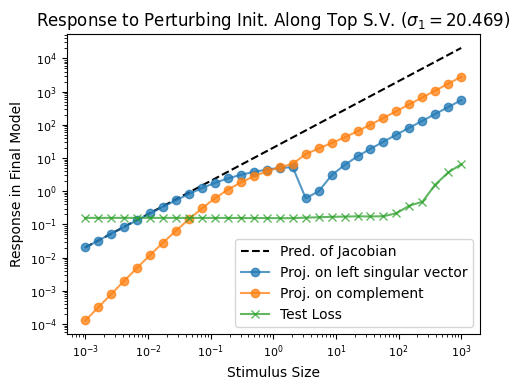

In [37]:
complements = []
bulk_y = []
responses = []

num = 0
grid = jnp.logspace(-3, 3, 30)
for stim in grid:
    perturbed_params, loss = train(
        params_0 + stim * jac_vh[num],
        X_train,
        Y_train,
        X_test,
        Y_test,
        apply_fn,
        TrainConfig(opt="sgd"),
    )
    delta = perturbed_params - params_f
    res = delta @ jac_u[:, num]
    complement = jnp.linalg.norm(delta - res * jac_u[:, num])

    complements.append(complement)
    bulk_y.append(loss)
    responses.append(res)

plt.figure(figsize=(5, 4))  # Adjust figure size to be more paper-friendly
plt.plot(grid, grid * jac_s[num], label="Pred. of Jacobian", c="black", linestyle="--")
plt.plot(
    grid,
    jnp.abs(jnp.array(responses)),
    marker="o",
    label="Proj. on left singular vector",
    alpha=0.75,
)
plt.plot(grid, complements, marker="o", label="Proj. on complement", alpha=0.75)
plt.plot(grid, bulk_y, marker="x", label="Test Loss", alpha=0.75)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Stimulus Size")
plt.ylabel("Response in Final Model")
plt.title(f"Response to Perturbing Init. Along Top S.V. ($\\sigma_1 = {jac_s[0]:.3f}$)")
plt.legend()

# Tight layout to ensure no clipping
plt.tight_layout()

# Show or save the plot
plt.savefig("top sv perturb.pdf", format="pdf")
plt.show()

## Restricted training

In [30]:
anti_losses = []
bulk_losses = []

chaotic_losses = []
stable_losses = []

ks = jnp.linspace(100, len(params_0), 20).astype(int)
for k in ks:
    indices = jnp.argsort(jnp.abs(jac_s - 1))
    anti_bulk = indices[-k:]
    bulk = indices[:k]

    p = jnp.zeros(k)

    # Anti-bulk
    subspace_fn = make_apply_subspace(model, unravel, params_0, jac_vh[anti_bulk])
    _, anti_loss = train(
        p, X_train, Y_train, X_test, Y_test, subspace_fn, TrainConfig(opt="sgd")
    )
    anti_losses.append(anti_loss)

    # Bulk
    subspace_fn = make_apply_subspace(model, unravel, params_0, jac_vh[bulk])
    _, loss = train(
        p, X_train, Y_train, X_test, Y_test, subspace_fn, TrainConfig(opt="sgd")
    )
    bulk_losses.append(loss)

    # Chaotic
    subspace_fn = make_apply_subspace(model, unravel, params_0, jac_vh[:k])
    _, loss = train(
        p, X_train, Y_train, X_test, Y_test, subspace_fn, TrainConfig(opt="sgd")
    )
    chaotic_losses.append(loss)

    # Stable
    subspace_fn = make_apply_subspace(model, unravel, params_0, jac_vh[-k:])
    _, loss = train(
        p, X_train, Y_train, X_test, Y_test, subspace_fn, TrainConfig(opt="sgd")
    )
    stable_losses.append(loss)

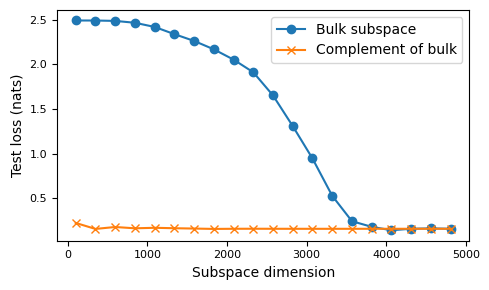

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.plot(ks, bulk_losses, marker="o", label="Bulk subspace")
plt.plot(ks, anti_losses, marker="x", label="Complement of bulk")
plt.xlabel("Subspace dimension")
plt.ylabel("Test loss (nats)")
plt.legend()

plt.tight_layout()
plt.savefig("subspace losses.pdf", format="pdf")

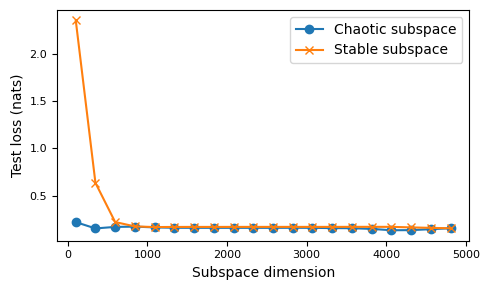

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.plot(ks, chaotic_losses, marker="o", label="Chaotic subspace")
plt.plot(ks, stable_losses, marker="x", label="Stable subspace")
plt.xlabel("Subspace dimension")
plt.ylabel("Test loss (nats)")
plt.legend()

plt.tight_layout()
plt.savefig("subspace losses2.pdf", format="pdf")

## Training on different distributions

In [33]:
key2 = jax.random.key(1)
Y_shuffled = jax.random.permutation(key2, Y_train)
X_noise = jax.random.uniform(key2, X_train.shape)

jac_shuffled, losses_shuffled = jac_fn(
    params_0, X_train, Y_shuffled, X_test, Y_test, apply_fn, TrainConfig(opt="sgd")
)
jac_noise, losses_noise = jac_fn(
    params_0, X_noise, Y_train, X_test, Y_test, apply_fn, TrainConfig(opt="sgd")
)

In [34]:
u_shuffled, s_shuffled, vh_shuffled = jnp.linalg.svd(jac_shuffled)
u_noise, s_noise, vh_noise = jnp.linalg.svd(jac_noise)

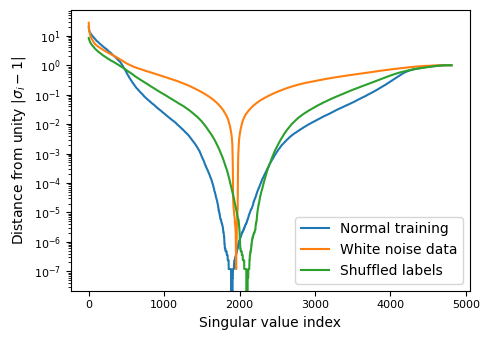

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3.5))
plt.plot(jnp.abs(jac_s - 1), label="Normal training")
plt.plot(jnp.abs(s_noise - 1), label="White noise data")
plt.plot(jnp.abs(s_shuffled - 1), label="Shuffled labels")
plt.xlabel("Singular value index")
plt.ylabel("Distance from unity $|\\sigma_i - 1|$")
plt.yscale("log")
plt.legend()

plt.tight_layout()
plt.savefig("noise bird.pdf", format="pdf")

## Perturbations

In [4]:
def get_delta(cfg, basis=None, return_jac: bool = True):
    if basis is not None:
        apply_fn = make_apply_subspace(model, unravel, params_0, basis)
        params0 = jnp.zeros(len(basis))
    else:
        apply_fn = make_apply_full(model, unravel)
        params0 = params_0

    params_f, _ = train(params0, X_train, Y_train, X_test, Y_test, apply_fn, cfg)
    if return_jac:
        jac, _ = jac_fn(params0, X_train, Y_train, X_test, Y_test, apply_fn, cfg)
        jac_svd = jnp.linalg.svd(jac)
    else:
        jac_svd = None

    return params0, params_f, jac_svd, apply_fn


params0, params_f, jac_svd, apply_fn = get_delta(TrainConfig())

In [5]:
X_fake = jax.random.normal(jax.random.key(0), (len(X_test), 64))
X_inverted = 1 - X_test

In [6]:
import optax

perturbed = jax.vmap(apply_fn, in_axes=(0, None))(params_f + jac_svd.Vh, X_inverted)
original = apply_fn(params_f, X_inverted)

all_kls = optax.kl_divergence(jax.nn.log_softmax(perturbed), jax.nn.softmax(original))
inverted_kls = all_kls.max(axis=-1)

perturbed = jax.vmap(apply_fn, in_axes=(0, None))(params_f + jac_svd.Vh, X_fake)
original = apply_fn(params_f, X_fake)

all_kls = optax.kl_divergence(jax.nn.log_softmax(perturbed), jax.nn.softmax(original))
fake_kls = all_kls.max(axis=-1)

perturbed = jax.vmap(apply_fn, in_axes=(0, None))(params_f + jac_svd.Vh, X_train)
original = apply_fn(params_f, X_train)

all_kls = optax.kl_divergence(jax.nn.log_softmax(perturbed), jax.nn.softmax(original))
train_kls = all_kls.max(axis=-1)

perturbed = jax.vmap(apply_fn, in_axes=(0, None))(params_f + jac_svd.Vh, X_test)
original = apply_fn(params_f, X_test)

all_kls = optax.kl_divergence(jax.nn.log_softmax(perturbed), jax.nn.softmax(original))
test_kls = all_kls.max(axis=-1)

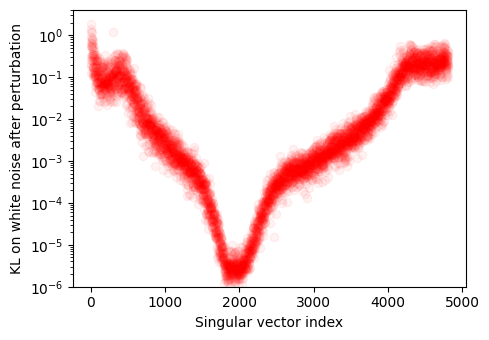

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3.5))  # Adjust figure size to be more paper-friendly
plt.scatter(
    jnp.arange(len(train_kls)), train_kls, alpha=0.05, label="sqrt(train KL)", c="red"
)
plt.yscale("log")
plt.xlabel("Singular vector index")
plt.ylabel("KL on white noise after perturbation")
plt.ylim(1e-6, 4)

plt.tight_layout()

plt.savefig("kl bird.pdf", format="pdf")

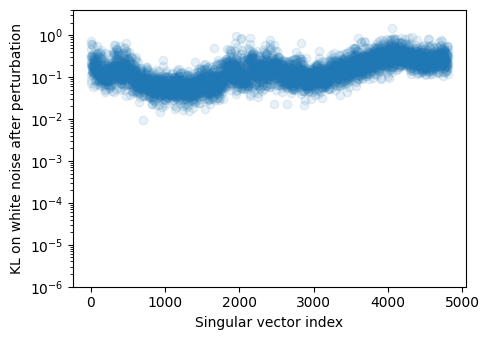

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3.5))  # Adjust figure size to be more paper-friendly
plt.scatter(jnp.arange(len(fake_kls)), jnp.abs(fake_kls), alpha=0.1, label="test KL")
plt.yscale("log")
plt.xlabel("Singular vector index")
plt.ylabel("KL on white noise after perturbation")
plt.ylim(1e-6, 4)

plt.tight_layout()

plt.savefig("kl random.pdf", format="pdf")

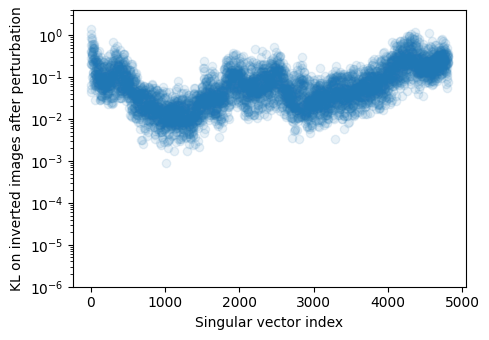

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3.5))  # Adjust figure size to be more paper-friendly
plt.scatter(
    jnp.arange(len(inverted_kls)), jnp.abs(inverted_kls), alpha=0.1, label="test KL"
)
plt.yscale("log")
plt.xlabel("Singular vector index")
plt.ylabel("KL on inverted images after perturbation")
plt.ylim(1e-6, 4)

plt.tight_layout()

plt.savefig("kl inverted.pdf", format="pdf")

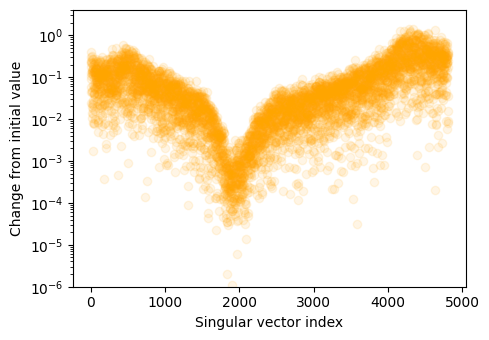

In [15]:
import matplotlib.pyplot as plt

deltas = jac_svd.Vh @ (params_f - params0)

plt.figure(figsize=(5, 3.5))  # Adjust figure size to be more paper-friendly
plt.scatter(
    jnp.arange(len(deltas)), jnp.abs(deltas), alpha=0.1, label="test KL", color="orange"
)
plt.yscale("log")
plt.xlabel("Singular vector index")
plt.ylabel("Change from initial value")
plt.ylim(1e-6, 4)

plt.tight_layout()

plt.savefig("deltas.pdf", format="pdf")